In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten

# preprocess data
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# MLP model
mlp_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

mlp_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

with tf.device('/GPU:0'):  # run on GPU
    mlp_model.fit(x_train, y_train, epochs=15, batch_size=64, validation_split=0.1) # train
    mlp_accuracy = mlp_model.evaluate(x_test, y_test, verbose=0)[1] # evaluate
print(f'\nAccuracy on test set (MLP): {mlp_accuracy:.2%}')

Epoch 1/15
844/844 [==============================] - 4s 4ms/step - loss: 0.2086 - accuracy: 0.9370 - val_loss: 0.1015 - val_accuracy: 0.9697
Epoch 2/15
844/844 [==============================] - 3s 3ms/step - loss: 0.0823 - accuracy: 0.9745 - val_loss: 0.0749 - val_accuracy: 0.9772
Epoch 3/15
844/844 [==============================] - 4s 4ms/step - loss: 0.0546 - accuracy: 0.9828 - val_loss: 0.0815 - val_accuracy: 0.9752
Epoch 4/15
844/844 [==============================] - 3s 4ms/step - loss: 0.0402 - accuracy: 0.9870 - val_loss: 0.0793 - val_accuracy: 0.9785
Epoch 5/15
844/844 [==============================] - 3s 3ms/step - loss: 0.0295 - accuracy: 0.9903 - val_loss: 0.0876 - val_accuracy: 0.9767
Epoch 6/15
844/844 [==============================] - 3s 3ms/step - loss: 0.0272 - accuracy: 0.9908 - val_loss: 0.0884 - val_accuracy: 0.9795
Epoch 7/15
844/844 [==============================] - 4s 4ms/step - loss: 0.0204 - accuracy: 0.9930 - val_loss: 0.0858 - val_accuracy: 0.9807
Epoch 

In [29]:
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Reshape

# reshape data
x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
x_test_reshaped = x_test.reshape(-1, 28, 28, 1)

# LeNet model
lenet_model = Sequential([
    Conv2D(6, kernel_size=(5, 5), padding='same', activation='sigmoid', input_shape=(28, 28, 1)),
    AveragePooling2D(pool_size=(2, 2), strides=2),
    Conv2D(16, kernel_size=(5, 5), activation='sigmoid'),
    AveragePooling2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(120, activation='sigmoid'),
    Dense(84, activation='sigmoid'),
    Dense(10, activation='softmax')
])

lenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

with tf.device('/GPU:0'):  # run on GPU
    lenet_model.fit(x_train_reshaped, y_train, epochs=15, batch_size=64, validation_split=0.1) # train
    lenet_accuracy = lenet_model.evaluate(x_test_reshaped, y_test, verbose=0)[1] # evaluate
print(f'\nAccuracy on test set (LeNet): {lenet_accuracy:.2%}')

Epoch 1/15
844/844 [==============================] - 5s 4ms/step - loss: 1.1362 - accuracy: 0.6278 - val_loss: 0.2837 - val_accuracy: 0.9187
Epoch 2/15
844/844 [==============================] - 5s 6ms/step - loss: 0.2611 - accuracy: 0.9224 - val_loss: 0.1596 - val_accuracy: 0.9532
Epoch 3/15
844/844 [==============================] - 4s 4ms/step - loss: 0.1753 - accuracy: 0.9469 - val_loss: 0.1210 - val_accuracy: 0.9653
Epoch 4/15
844/844 [==============================] - 4s 4ms/step - loss: 0.1314 - accuracy: 0.9599 - val_loss: 0.0974 - val_accuracy: 0.9708
Epoch 5/15
844/844 [==============================] - 5s 5ms/step - loss: 0.1040 - accuracy: 0.9684 - val_loss: 0.0837 - val_accuracy: 0.9748
Epoch 6/15
844/844 [==============================] - 4s 4ms/step - loss: 0.0879 - accuracy: 0.9728 - val_loss: 0.0735 - val_accuracy: 0.9798
Epoch 7/15
844/844 [==============================] - 4s 4ms/step - loss: 0.0754 - accuracy: 0.9766 - val_loss: 0.0661 - val_accuracy: 0.9808
Epoch 

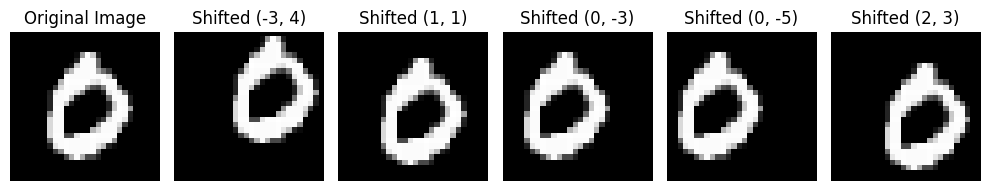


1/1 [==============================] - 0s 17ms/step
MLP prediction for shift (-3, 4): 6
MLP prediction for shift (1, 1): 0
MLP prediction for shift (0, -3): 0
MLP prediction for shift (0, -5): 2
MLP prediction for shift (2, 3): 2

1/1 [==============================] - 0s 16ms/step
LeNet prediction for shift (-3, 4): 6
LeNet prediction for shift (1, 1): 0
LeNet prediction for shift (0, -3): 0
LeNet prediction for shift (0, -5): 8
LeNet prediction for shift (2, 3): 0


In [57]:
import matplotlib.pyplot as plt
from scipy.ndimage import shift

def display_images(original, shifted_images, titles):
    num_images = len(shifted_images)
    fig, axes = plt.subplots(1, num_images + 1, figsize=(10, 5))

    # original image
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # shifted images
    for i, (image, title) in enumerate(zip(shifted_images, titles)):
        axes[i + 1].imshow(image, cmap='gray')
        axes[i + 1].set_title(title)
        axes[i + 1].axis('off')
    plt.tight_layout()
    plt.show()

def load_MNIST():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    x_train = x_train / 255.0
    x_test = x_test / 255.0
    x_train_reshaped = x_train.reshape(-1, 28, 28, 1)
    x_test_reshaped = x_test.reshape(-1, 28, 28, 1)
    return x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped

def shift_image(image, shift_value): # shift image
    return shift(image, shift=shift_value, mode='nearest')

def mlp_predict(model, images): # predict with MLP
    print()
    predictions = model.predict(images)
    return np.argmax(predictions, axis=1)

def lenet_predict(model, images): # predict with LeNet
    print()
    predictions = model.predict(images)
    return np.argmax(predictions, axis=1)

if __name__ == "__main__":

    x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped = load_MNIST() # load and preprocess data

    index = 3 # choose an image
    original_image = x_test[index]

    shift_values = [(-3, 4), (1, 1), (0, -3), (0, -5), (2, 3)] # shift values

    # display original and shifted images
    shifted_images = [shift_image(original_image, sv) for sv in shift_values]
    display_images(original_image, shifted_images, [f"Shifted {sv}" for sv in shift_values])

    # MLP predictions
    shifted_images_mlp = np.array(shifted_images).reshape(len(shifted_images), 28, 28) # Reshape for MLP
    mlp_predictions = mlp_predict(mlp_model, shifted_images_mlp)
    for i, pred in enumerate(mlp_predictions):
        print(f"MLP prediction for shift {shift_values[i]}: {pred}")

    # LeNet predictions
    shifted_images_lenet = shifted_images_mlp.reshape(len(shifted_images), 28, 28, 1) # Reshape for LeNet
    lenet_predictions = lenet_predict(lenet_model, shifted_images_lenet)
    for i, pred in enumerate(lenet_predictions):
        print(f"LeNet prediction for shift {shift_values[i]}: {pred}")

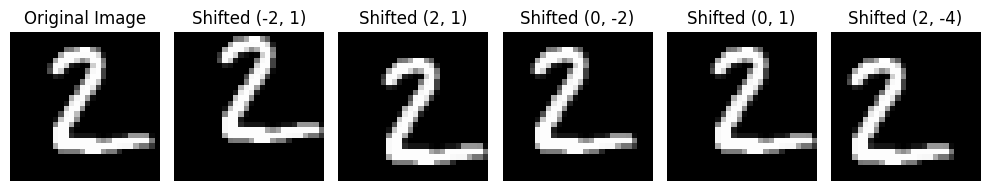


1/1 [==============================] - 0s 16ms/step
MLP prediction for shift (-2, 1): 2
MLP prediction for shift (2, 1): 2
MLP prediction for shift (0, -2): 2
MLP prediction for shift (0, 1): 2
MLP prediction for shift (2, -4): 5

1/1 [==============================] - 0s 16ms/step
LeNet prediction for shift (-2, 1): 2
LeNet prediction for shift (2, 1): 2
LeNet prediction for shift (0, -2): 2
LeNet prediction for shift (0, 1): 2
LeNet prediction for shift (2, -4): 2


In [87]:
if __name__ == "__main__":

    x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped = load_MNIST() # load and preprocess data

    index = 1 # choose an image
    original_image = x_test[index]

    shift_values = [(-2, 1), (2, 1), (0, -2), (0, 1), (2, -4)] # shift values

    # display original and shifted images
    shifted_images = [shift_image(original_image, sv) for sv in shift_values]
    display_images(original_image, shifted_images, [f"Shifted {sv}" for sv in shift_values])

    # MLP predictions
    shifted_images_mlp = np.array(shifted_images).reshape(len(shifted_images), 28, 28) # Reshape for MLP
    mlp_predictions = mlp_predict(mlp_model, shifted_images_mlp)
    for i, pred in enumerate(mlp_predictions):
        print(f"MLP prediction for shift {shift_values[i]}: {pred}")

    # LeNet predictions
    shifted_images_lenet = shifted_images_mlp.reshape(len(shifted_images), 28, 28, 1) # Reshape for LeNet
    lenet_predictions = lenet_predict(lenet_model, shifted_images_lenet)
    for i, pred in enumerate(lenet_predictions):
        print(f"LeNet prediction for shift {shift_values[i]}: {pred}")

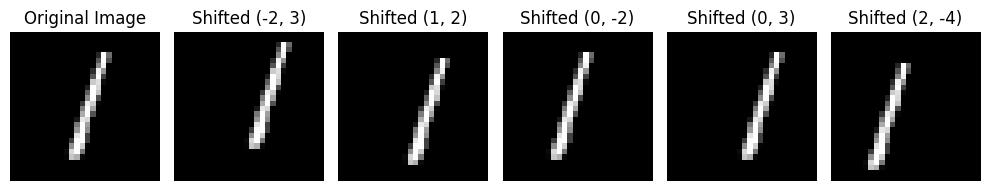


1/1 [==============================] - 0s 18ms/step
MLP prediction for shift (-2, 3): 1
MLP prediction for shift (1, 2): 1
MLP prediction for shift (0, -2): 1
MLP prediction for shift (0, 3): 4
MLP prediction for shift (2, -4): 8

1/1 [==============================] - 0s 17ms/step
LeNet prediction for shift (-2, 3): 1
LeNet prediction for shift (1, 2): 1
LeNet prediction for shift (0, -2): 1
LeNet prediction for shift (0, 3): 1
LeNet prediction for shift (2, -4): 1


In [63]:
if __name__ == "__main__":

    x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped = load_MNIST() # load and preprocess data

    index = 2 # choose an image
    original_image = x_test[index]

    shift_values = [(-2, 3), (1, 2), (0, -2), (0, 3), (2, -4)] # shift values

    # display original and shifted images
    shifted_images = [shift_image(original_image, sv) for sv in shift_values]
    display_images(original_image, shifted_images, [f"Shifted {sv}" for sv in shift_values])

    # MLP predictions
    shifted_images_mlp = np.array(shifted_images).reshape(len(shifted_images), 28, 28) # Reshape for MLP
    mlp_predictions = mlp_predict(mlp_model, shifted_images_mlp)
    for i, pred in enumerate(mlp_predictions):
        print(f"MLP prediction for shift {shift_values[i]}: {pred}")

    # LeNet predictions
    shifted_images_lenet = shifted_images_mlp.reshape(len(shifted_images), 28, 28, 1) # Reshape for LeNet
    lenet_predictions = lenet_predict(lenet_model, shifted_images_lenet)
    for i, pred in enumerate(lenet_predictions):
        print(f"LeNet prediction for shift {shift_values[i]}: {pred}")

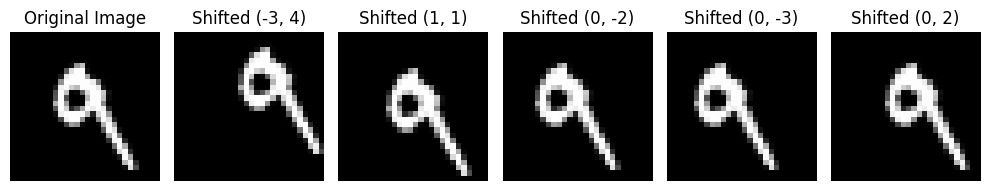


1/1 [==============================] - 0s 17ms/step
MLP prediction for shift (-3, 4): 3
MLP prediction for shift (1, 1): 9
MLP prediction for shift (0, -2): 9
MLP prediction for shift (0, -3): 5
MLP prediction for shift (0, 2): 9

1/1 [==============================] - 0s 18ms/step
LeNet prediction for shift (-3, 4): 9
LeNet prediction for shift (1, 1): 9
LeNet prediction for shift (0, -2): 9
LeNet prediction for shift (0, -3): 9
LeNet prediction for shift (0, 2): 9


In [69]:
if __name__ == "__main__":

    x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped = load_MNIST() # load and preprocess data

    index = 7 # choose an image
    original_image = x_test[index]

    shift_values = [(-3, 4), (1, 1), (0, -2), (0, -3), (0, 2)] # shift values

    # display original and shifted images
    shifted_images = [shift_image(original_image, sv) for sv in shift_values]
    display_images(original_image, shifted_images, [f"Shifted {sv}" for sv in shift_values])

    # MLP predictions
    shifted_images_mlp = np.array(shifted_images).reshape(len(shifted_images), 28, 28) # Reshape for MLP
    mlp_predictions = mlp_predict(mlp_model, shifted_images_mlp)
    for i, pred in enumerate(mlp_predictions):
        print(f"MLP prediction for shift {shift_values[i]}: {pred}")

    # LeNet predictions
    shifted_images_lenet = shifted_images_mlp.reshape(len(shifted_images), 28, 28, 1) # Reshape for LeNet
    lenet_predictions = lenet_predict(lenet_model, shifted_images_lenet)
    for i, pred in enumerate(lenet_predictions):
        print(f"LeNet prediction for shift {shift_values[i]}: {pred}")

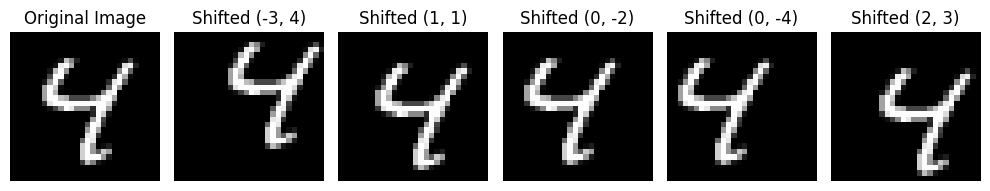


1/1 [==============================] - 0s 17ms/step
MLP prediction for shift (-3, 4): 5
MLP prediction for shift (1, 1): 4
MLP prediction for shift (0, -2): 4
MLP prediction for shift (0, -4): 6
MLP prediction for shift (2, 3): 4

1/1 [==============================] - 0s 17ms/step
LeNet prediction for shift (-3, 4): 7
LeNet prediction for shift (1, 1): 4
LeNet prediction for shift (0, -2): 4
LeNet prediction for shift (0, -4): 8
LeNet prediction for shift (2, 3): 4


In [81]:
if __name__ == "__main__":

    x_train, y_train, x_test, y_test, x_train_reshaped, x_test_reshaped = load_MNIST() # load and preprocess data

    index = 6 # choose an image
    original_image = x_test[index]

    shift_values = [(-3, 4), (1, 1), (0, -2), (0, -4), (2, 3)] # shift values

    # display original and shifted images
    shifted_images = [shift_image(original_image, sv) for sv in shift_values]
    display_images(original_image, shifted_images, [f"Shifted {sv}" for sv in shift_values])

    # MLP predictions
    shifted_images_mlp = np.array(shifted_images).reshape(len(shifted_images), 28, 28) # Reshape for MLP
    mlp_predictions = mlp_predict(mlp_model, shifted_images_mlp)
    for i, pred in enumerate(mlp_predictions):
        print(f"MLP prediction for shift {shift_values[i]}: {pred}")

    # LeNet predictions
    shifted_images_lenet = shifted_images_mlp.reshape(len(shifted_images), 28, 28, 1) # Reshape for LeNet
    lenet_predictions = lenet_predict(lenet_model, shifted_images_lenet)
    for i, pred in enumerate(lenet_predictions):
        print(f"LeNet prediction for shift {shift_values[i]}: {pred}")